## Indonesia Emas 2045 - Life Hack Kelompok 2 (2024)

In [24]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller
%matplotlib widget
import matplotlib.pyplot as plt
import itertools
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from Poly import *

#### Import data GDP

In [84]:
# Membaca data dari file yang diunggah
file_path = 'data_GDP.csv'
data = pd.read_csv(file_path)

# Menampilkan beberapa baris pertama dari data untuk melihat strukturnya
data


,Year,GDP
0,1967,5.667757e+09
1,1968,7.076465e+09
2,1969,8.337423e+09
3,1970,9.150685e+09
4,1971,9.333536e+09
5,1972,1.099759e+10
6,1973,1.627325e+10
7,1974,2.580241e+10
8,1975,3.046386e+10
9,1976,3.726916e+10


#### Ploting data GDP dari tahun 1967-2024

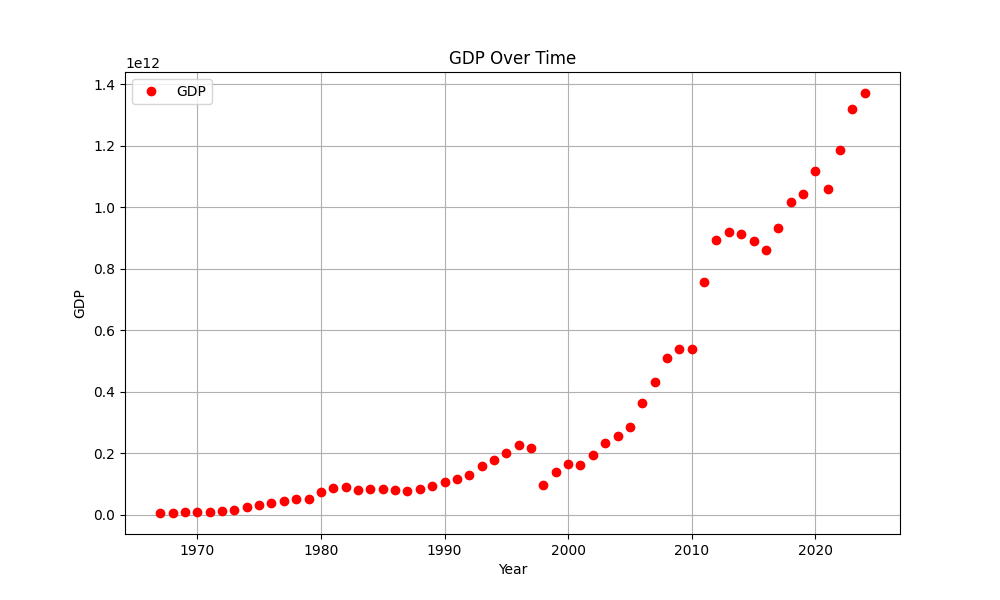

In [26]:
# Membuat plot data historis GDP
fig, ax = plt.subplots (figsize=(10, 6))

ax.plot(data['Year'], data['GDP'], 'or', label='GDP')
ax.set_xlabel('Year')
ax.set_ylabel('GDP')
ax.set_title('GDP Over Time')

ax.legend()

plt.grid (True)
plt.show()


### Curve fitting dengan Kiusalas

#### Mencari koefisien 

In [161]:
while True:

    try:

        m = eval (input ("\nDegree of polynomial ==> "))
        coeff = polyFit (data['Year'], data['GDP'], m)
        print("Coefficients are:\n",coeff)
        print("Std. deviation =", stdDev (coeff, data['Year'], data['GDP']) )
    
    except SyntaxError: break

input ("Finished. Press return to exit")

Coefficients are:
 [-7.92860282e+16  1.20512534e+14 -6.10592292e+10  1.03122664e+07]
Std. deviation = 71456551061.97539


''

#### Mencari hasil fitting

In [162]:
m = len (coeff)
x1 = min (data['Year'])
x2 = max (data['Year'])
dx = (x2 - x1)/20.0
x_fitting = np.arange(x1,x2 + dx/10.0,dx)
y_fitting = np.zeros((len(x_fitting)))*1.0

for i in range(m):
    y_fitting = y_fitting + coeff[i] * x_fitting ** i
    print (y_fitting)

[-7.92860282e+16 -7.92860282e+16 -7.92860282e+16 -7.92860282e+16
 -7.92860282e+16 -7.92860282e+16 -7.92860282e+16 -7.92860282e+16
 -7.92860282e+16 -7.92860282e+16 -7.92860282e+16 -7.92860282e+16
 -7.92860282e+16 -7.92860282e+16 -7.92860282e+16 -7.92860282e+16
 -7.92860282e+16 -7.92860282e+16 -7.92860282e+16 -7.92860282e+16
 -7.92860282e+16]
[1.57762126e+17 1.58105587e+17 1.58449047e+17 1.58792508e+17
 1.59135969e+17 1.59479429e+17 1.59822890e+17 1.60166351e+17
 1.60509812e+17 1.60853272e+17 1.61196733e+17 1.61540194e+17
 1.61883655e+17 1.62227115e+17 1.62570576e+17 1.62914037e+17
 1.63257497e+17 1.63600958e+17 1.63944419e+17 1.64287880e+17
 1.64631340e+17]
[-7.84814660e+16 -7.88230912e+16 -7.91657084e+16 -7.95093174e+16
 -7.98539183e+16 -8.01995111e+16 -8.05460959e+16 -8.08936725e+16
 -8.12422411e+16 -8.15918015e+16 -8.19423539e+16 -8.22938982e+16
 -8.26464344e+16 -8.29999624e+16 -8.33544824e+16 -8.37099943e+16
 -8.40664982e+16 -8.44239939e+16 -8.47824815e+16 -8.51419610e+16
 -8.550243

#### Plot hasil fitting

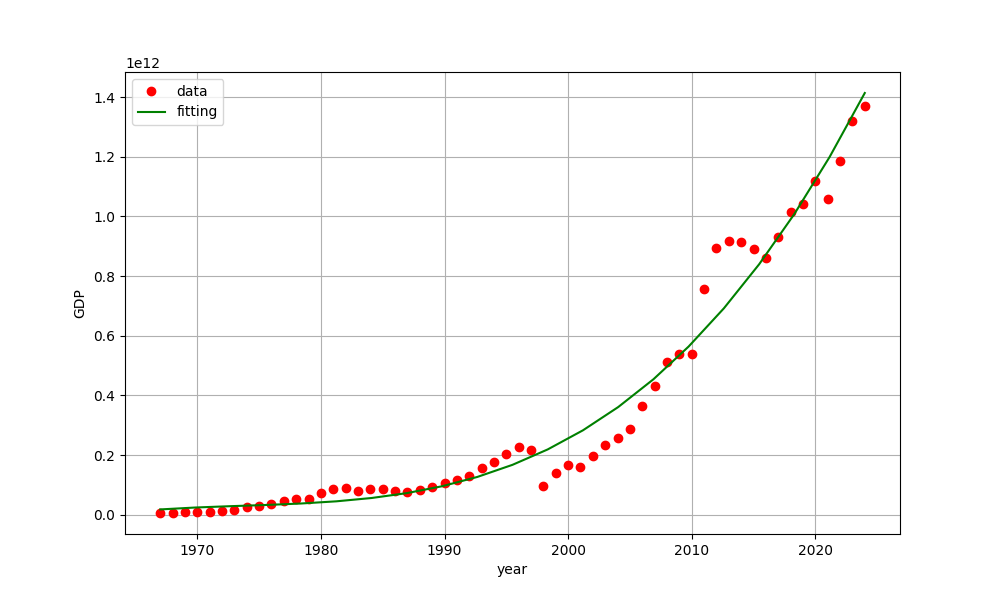

In [163]:
fig, ax2 = plt.subplots (figsize=(10, 6))

ax2.plot (data['Year'], data['GDP'], 'o', color="red", label="data")
ax2.plot (x_fitting, y_fitting, color="green", label="fitting")

ax2.set_xlabel ('year')
ax2.set_ylabel ('GDP')
plt.grid (True)

plt.legend (loc="best")
plt.show()

#### Melakukan ADF test untuk memeriksa stasioneritas

In [164]:

result = adfuller(data['GDP'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

for key, value in result[4].items():
    print('Critical Values:')
    print(f'   {key}, {value}')


ADF Statistic: 2.9316628795291946
p-value: 1.0
Critical Values:
   1%, -3.5506699942762414
Critical Values:
   5%, -2.913766394626147
Critical Values:
   10%, -2.5946240473991997


In [165]:
# Melakukan differencing
data['GDP_diff'] = data['GDP'].diff().dropna()

# Melakukan ADF test lagi untuk data yang telah di-differencing

result_diff = adfuller (data['GDP_diff'].dropna())
print('ADF Statistic:', result_diff[0])
print('p-value:', result_diff[1])
for key, value in result_diff[4].items():
    print('Critical Values:')
    print(f'   {key}, {value}')


ADF Statistic: -5.463490183941523
p-value: 2.488404839689482e-06
Critical Values:
   1%, -3.552928203580539
Critical Values:
   5%, -2.9147306250000002
Critical Values:
   10%, -2.595137155612245


#### Ploting data yang telah di-differencing

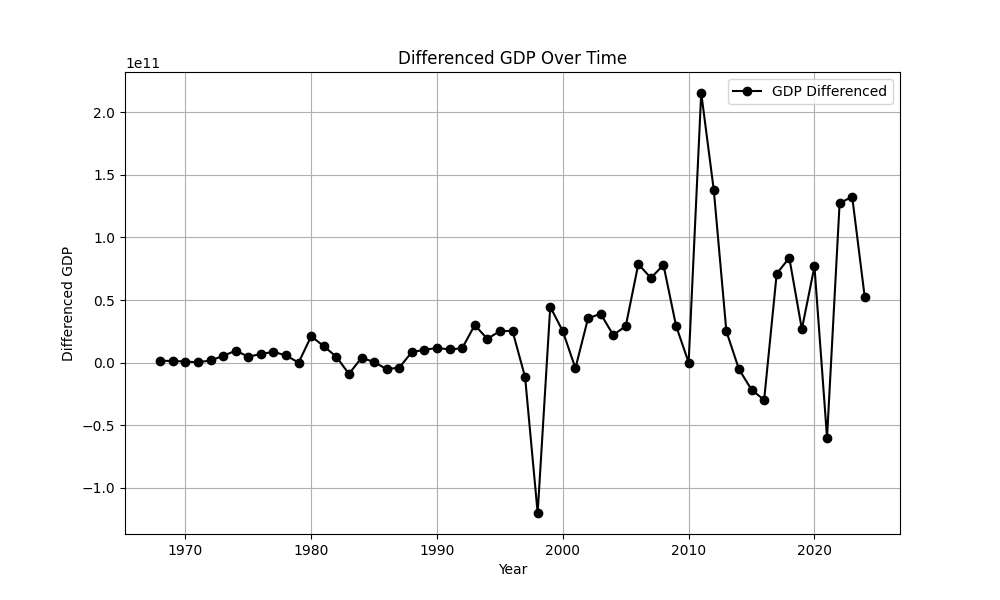

In [166]:

fig, ax1 = plt.subplots (figsize=(10, 6))
ax1.plot(data['Year'], data['GDP_diff'], 'o-', label='GDP Differenced', color="black")

ax1.set_xlabel('Year')
ax1.set_ylabel('Differenced GDP')
ax1.set_title('Differenced GDP Over Time')

plt.grid (True)
plt.legend()
plt.show()

#### Grid Search untuk mencari parameter ARIMA terbaik

In [167]:
p = d = q = range(0, 3)
pdq = list (itertools.product(p, d, q))

best_aic = np.inf
best_pdq = None

for param in pdq:
    try:
        model = ARIMA(data['GDP'], order=param)
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_pdq = param
    except:
        continue

#print(f'Best ARIMA parameters: {best_pdq} with AIC: {best_aic}')

# Training Model dengan parameter terbaik
best_model = ARIMA (data['GDP'], order=best_pdq)
best_model_fit = best_model.fit()

/Users/eveambergoodmon/Documents/Belajar Python/Analisis Numerik/Anum/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/eveambergoodmon/Documents/Belajar Python/Analisis Numerik/Anum/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/eveambergoodmon/Documents/Belajar Python/Analisis Numerik/Anum/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/eveambergoodmon/Documents/Belajar Python/Analisis Numerik/Anum/lib/python3.10/site-packages/statsmodels/tsa/statespace/sari

#### Menghitung Prediksi 20 tahun 

In [168]:
# Prediksi 20 tahun ke depan
forecast_steps = 21
forecast = best_model_fit.get_forecast (steps=forecast_steps)

# Mengambil DataFrame hasil forecast
forecast_summary = forecast.summary_frame()

# Membuat indeks baru berdasarkan periode prediksi (dalam bentuk integer)
last_year = data.index[-1]
forecast_years = range (2025, 2046)

# Mengganti indeks hasil forecast dengan indeks baru
forecast_summary.index = forecast_years

# Menampilkan DataFrame hasil forecast dengan indeks baru
print(forecast_summary)


GDP           mean       mean_se  mean_ci_lower  mean_ci_upper
2025  1.419073e+12  5.093186e+10   1.319249e+12   1.518898e+12
2026  1.469660e+12  8.451882e+10   1.304006e+12   1.635314e+12
2027  1.520247e+12  1.119952e+11   1.300740e+12   1.739753e+12
2028  1.570834e+12  1.373512e+11   1.301630e+12   1.840037e+12
2029  1.621420e+12  1.618129e+11   1.304273e+12   1.938568e+12
2030  1.672007e+12  1.859300e+11   1.307591e+12   2.036423e+12
2031  1.722594e+12  2.099945e+11   1.311012e+12   2.134176e+12
2032  1.773181e+12  2.341783e+11   1.314200e+12   2.232162e+12
2033  1.823767e+12  2.585885e+11   1.316943e+12   2.330591e+12
2034  1.874354e+12  2.832950e+11   1.319106e+12   2.429602e+12
2035  1.924941e+12  3.083448e+11   1.320596e+12   2.529285e+12
2036  1.975527e+12  3.337694e+11   1.321352e+12   2.629703e+12
2037  2.026114e+12  3.595906e+11   1.321330e+12   2.730899e+12
2038  2.076701e+12  3.858230e+11   1.320502e+12   2.832900e+12
2039  2.127288e+12  4.124765e+11   1.318849e+12   2.935

#### Ploting hasil prediksi data 20 tahun kemudian

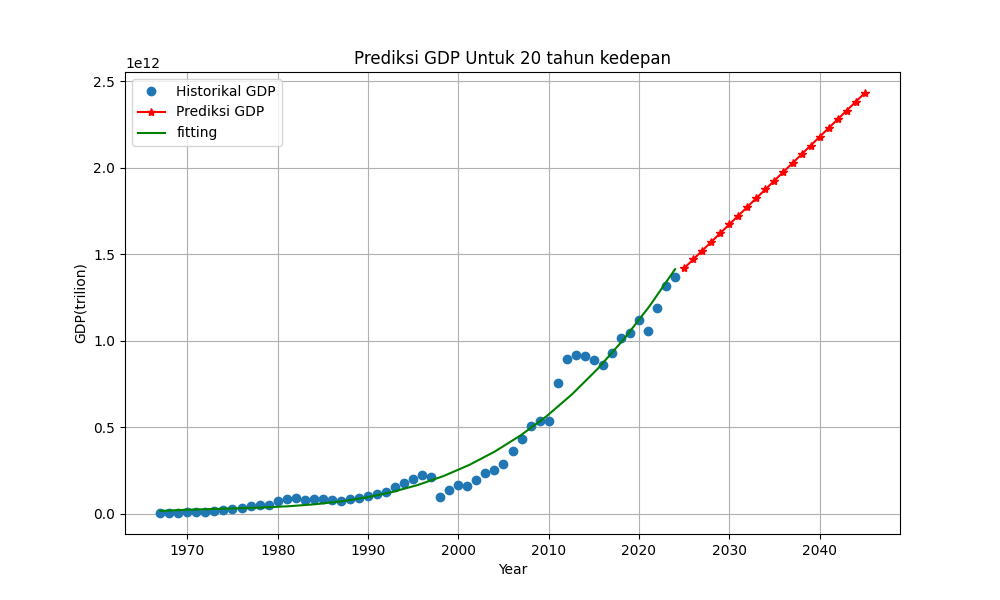

In [169]:
# Visualisasi Hasil Prediksi

fig, ax3 = plt.subplots (figsize=(10, 6))

ax3.plot(data['Year'], data['GDP'], 'o', label='Historikal GDP')
ax3.plot(forecast_summary.index, forecast_summary['mean'], '-*', label='Prediksi GDP', color='red')
ax3.plot (x_fitting, y_fitting, color="green", label="fitting")

ax3.set_xlabel('Year')
ax3.set_ylabel('GDP(trilion)')
ax3.set_title('Prediksi GDP Untuk 20 tahun kedepan')

plt.grid (True)
plt.legend()
plt.show()

#### Curve Fitting dengan Scipy

In [170]:
from scipy.optimize import curve_fit

def polynomial(x, a, b):
    #return a*(x**2) + b*x + c
    return a*x + b

def y_fit (x_data, y_data):
    
    # Perform the curve fitting
    params, covariance = curve_fit(polynomial, x_data, y_data)

    # Extract the parameters
    a, b= params
    x_fit = np.linspace (min (x_data), max (x_data) *3, 500)
    # Generate fitted y values
    val = polynomial (x_fit, a, b)
    return val

#### Sorted data 

In [171]:
data_GDP_sorted = pd.read_csv ('data_GDP_SORTED.csv')
data_GDP_sorted.set_index ('tahundipake', inplace=True)

#### GDP vs UMR

In [172]:
data_UMR = pd.read_csv ('UMR.csv')
data_UMR

# Menetapkan kolom Year sebagai indeks (dalam bentuk integer)
data_UMR.set_index('Year', inplace=False)

# Menampilkan beberapa baris pertama dari data untuk melihat strukturnya
data_UMR.head ()

,Year,UMR
0,1999,175400
1,2000,216500
2,2001,290500
3,2003,414700
4,1998,150900


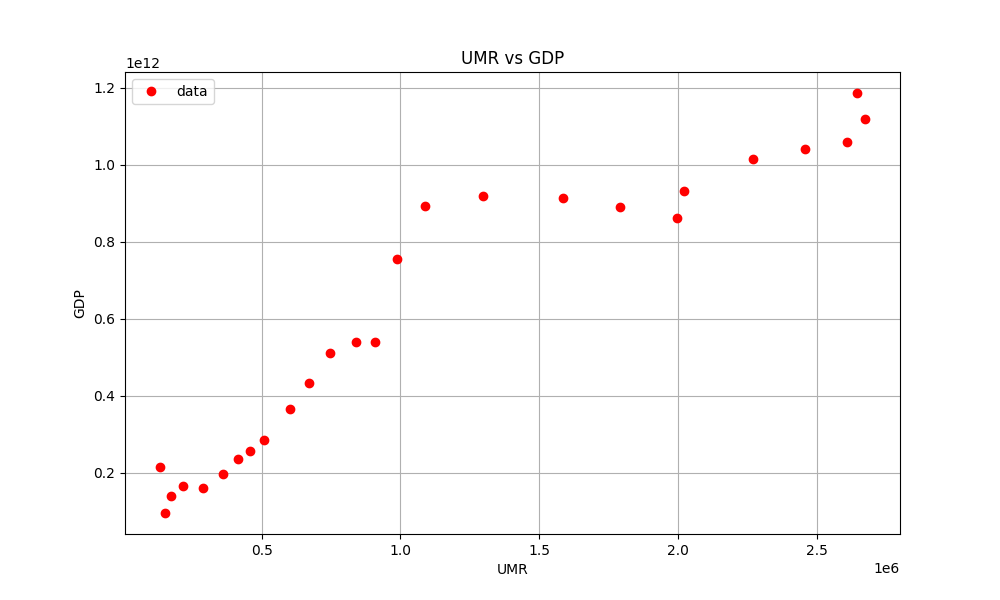

In [173]:
fig, ax5 = plt.subplots (figsize=(10, 6))

ax5.plot(data_UMR['UMR'], data_GDP_sorted['GDPdipake'], 'o', color='red', label='data')
ax5.set_xlabel('UMR')
ax5.set_ylabel('GDP')
ax5.set_title('UMR vs GDP')

ax5.legend()

plt.grid (True)
plt.show()

In [174]:
x_fit1 = np.linspace (min (data_UMR['UMR']), max (data_UMR['UMR']) *3, 500)
#y_fit1 = polynomial (x_fit1, y_fit (data_UMR['UMR'], data['GDP'][30:56]))

/var/folders/1p/qcgncvdj0mqb2m0t189tyyt00000gn/T/ipykernel_890/1553077310.py:10: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(polynomial, x_data, y_data)


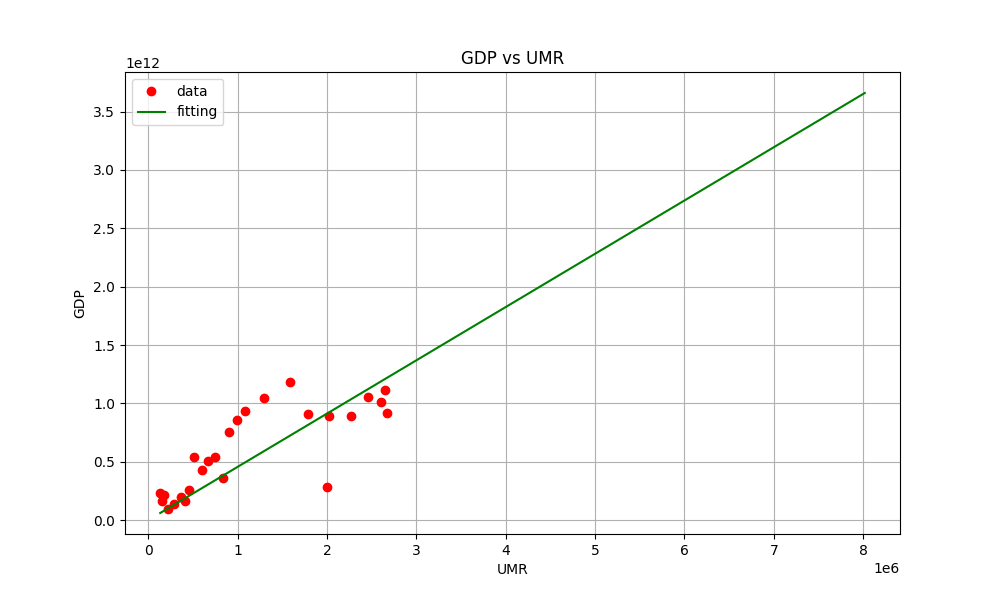

In [175]:
fig, ax6 = plt.subplots (figsize=(10, 6))

ax6.plot (data_UMR['UMR'], data['GDP'][30:56], 'o', color="red", label="data")
ax6.plot (x_fit1, y_fit (data_UMR['UMR'], data['GDP'][30:56]), color="green", label="fitting")

ax6.set_xlabel ('UMR')
ax6.set_ylabel ('GDP')
ax6.set_title ('GDP vs UMR')

plt.grid (True)

plt.legend (loc="best")
plt.show()

#### GDP vs Investasi

In [176]:
data_Investasi = pd.read_csv ('Investasi.csv')
data_Investasi

# Menetapkan kolom Year sebagai indeks (dalam bentuk integer)
data_Investasi.set_index ('Tahun', inplace=True)

# Menampilkan beberapa baris pertama dari data untuk melihat strukturnya
data_Investasi.head ()
data_GDP_sorted.head ()

,Year,GDP,GDPdipake
tahundipake,,,
1999,1967,5.667757e+09,1.400010e+11
2000,1968,7.076465e+09,1.650210e+11
2001,1969,8.337423e+09,1.604470e+11
2003,1970,9.150685e+09,2.347720e+11
1998,1971,9.333536e+09,9.544555e+10


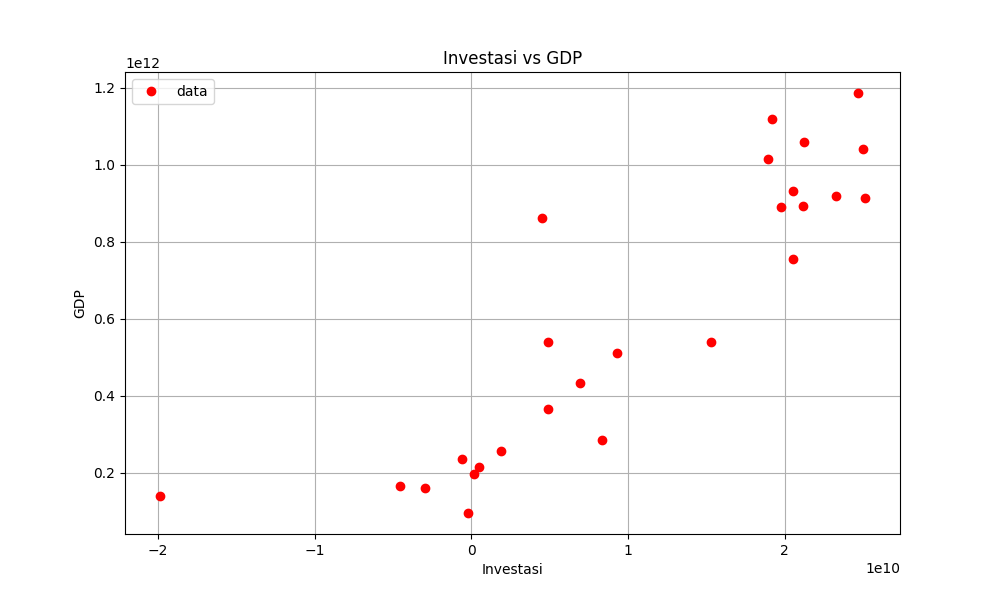

In [177]:
fig, ax7 = plt.subplots (figsize=(10, 6))

ax7.plot(data_Investasi['Investasi Luar'], data_GDP_sorted['GDPdipake'], 'or', label='data')
ax7.set_xlabel('Investasi')
ax7.set_ylabel('GDP')
ax7.set_title('Investasi vs GDP')

ax7.legend()

plt.grid (True)
plt.show()

In [178]:
x_fit1 = np.linspace (min (data_Investasi['Investasi Luar']), max (data_Investasi['Investasi Luar']) *3, 500)

/var/folders/1p/qcgncvdj0mqb2m0t189tyyt00000gn/T/ipykernel_890/1553077310.py:10: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(polynomial, x_data, y_data)


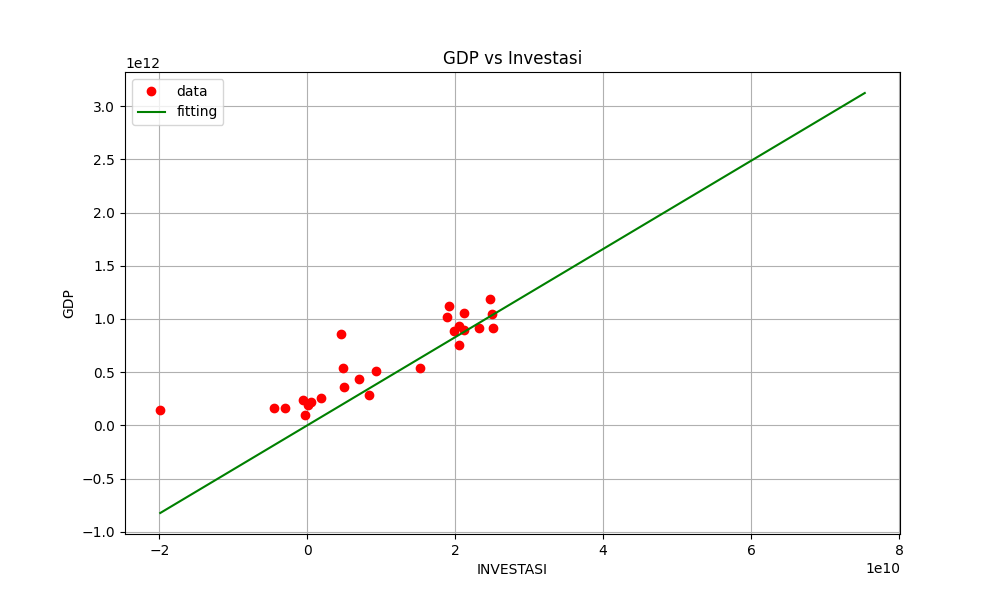

In [179]:
fig, ax8 = plt.subplots (figsize=(10, 6))

ax8.plot (data_Investasi['Investasi Luar'], data_GDP_sorted['GDPdipake'], 'o', color="red", label="data")
ax8.plot (x_fit1, y_fit (data_Investasi['Investasi Luar'], data_GDP_sorted['GDPdipake']), color="green", label="fitting")

ax8.set_xlabel ('INVESTASI')
ax8.set_ylabel ('GDP')
ax8.set_title ('GDP vs Investasi')

plt.grid (True)


plt.legend (loc="best")
plt.show()
